# Определение возраста покупателей

## Подготовка данных

### Загрузка библиотек и файлов

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import tensorflow as tf

Загрузим файл с данными.

* Изображения расположены в отдельных файлах собранных в одну директорию. Для работы с ними требуется использовать метод ImageDataGenerator — flow_from_dataframe.
* target_size=(224, 224) — аргумент с шириной и высотой, к которым будут приводиться изображения. В папках могут лежать изображения разного размера, а нейронным сетям нужно, чтобы все изображения были одинаковые.
* batch_size=16 — количество изображений в батче. Чем больше изображений, тем лучше обучится сеть. Много фотографий в памяти GPU не поместится, поэтому 16 — это оптимальный размер, с которой можно стартовать.
* сlass_mode='raw' — аргумент, который указывает тип выдачи метки классов.

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
datagen = ImageDataGenerator(rescale=1./255)
gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345)

Found 7591 validated image filenames.


In [3]:
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## Исследовательский анализ данных

* Посмотрим на размер выборки.
* Построим график распределения возраста в выборке.
* Напечатаем на экране 10–15 фотографий и посмотрим, как устроен датасет.
* Сделаем выводы о том, как результаты исследования повлияют на обучение модели.

In [4]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


* В датасете 2 колонки: file_name - название файла и real_age - возраст. Всего 7591 значений (фотографий).  
* Пропущенных значений нет.  
* Типы данных соответствуют их сущностям: file_name (название файла) имеет тип object, real_age (возраст) - целочисленные значения, тип int.

In [5]:
#Проверим датасет на явные дубликаты
labels.duplicated().sum()

0

In [6]:
#Выведем основную информацию о датасете
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


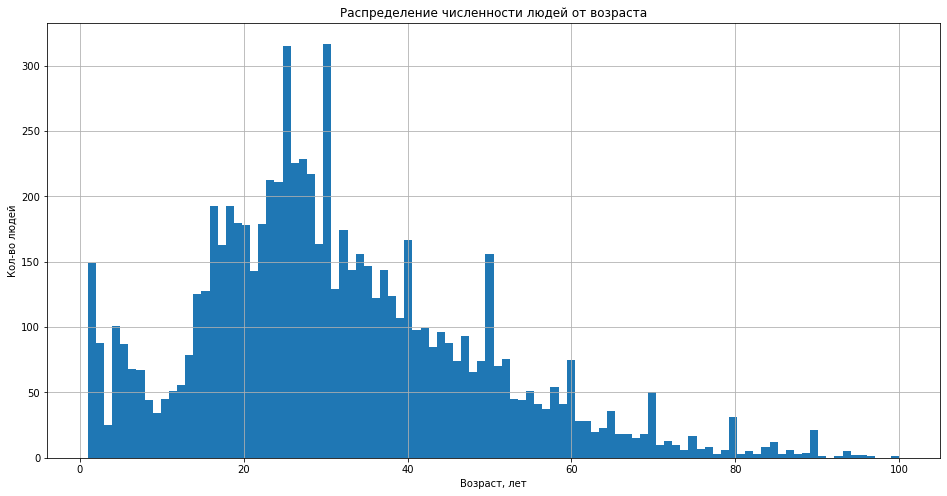

In [7]:
#Дополнительно построим график распределение возраста

labels['real_age'].plot(kind='hist', bins=100, figsize=(16, 8), grid=True)
plt.title('Распределение численности людей от возраста')
plt.ylabel('Кол-во людей')
plt.xlabel('Возраст, лет');

* Данные имеют распределение близкое к нормальному (от 1 до 100 лет). 
* Есть несколько ярко выраженных пиков. Большое количество детей в возрасте 1 года. Возможно это связано с округлением возраста детей до года в большую сторону. Еще два больших пика расположены в диапазоне 25-30 лет. Менее выраженные пики можно отметить в юбилейные годы, возможно, это связано с тем, что в праздники люди делают больше фотографий. 
* Средний возраст людей на фотографиях 31 год
* Самому молодому на фотографии 1 год, самому старшему 100 лет
* Большая часть людей на фото в диапазоне 18 - 40 лет

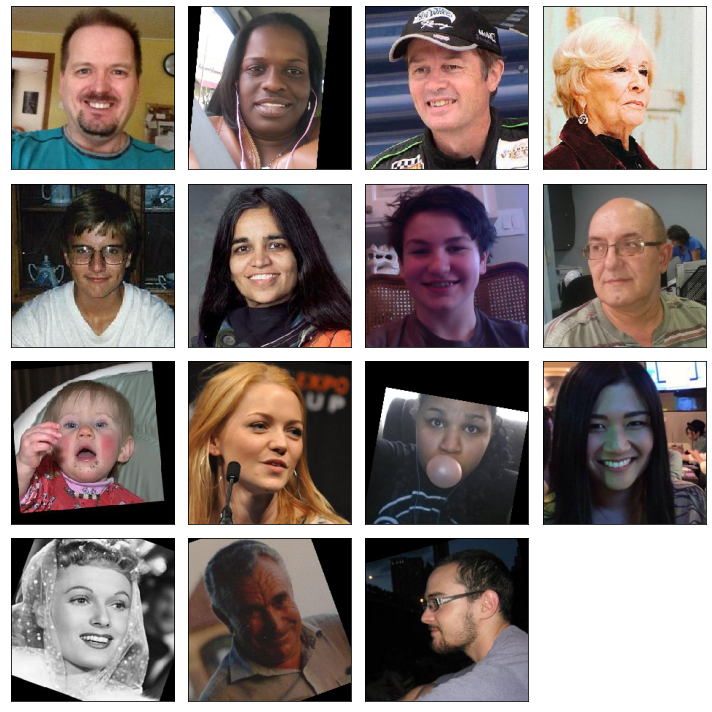

In [8]:
#Выведем 15 фото

features, target = next(gen_flow)

fig = plt.figure(figsize=(10,10))
for i in range(15):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(features[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

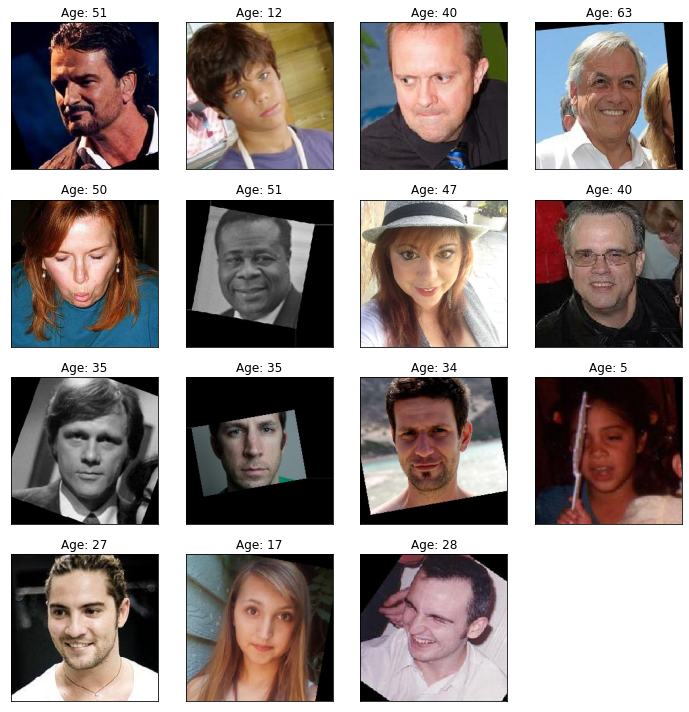

In [9]:
#Выведем 15 фото с подписями возрастов

features, target = next(gen_flow)

fig = plt.figure(figsize=(10, 10))
for i in range(15):
    ax = fig.add_subplot(4, 4, i+1)
    ax.imshow(features[i])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Age: {int(target[i])}')
    plt.tight_layout()

plt.show()

Датасет содержит файлы фотографий множества людей разного возраста и пола. На фото представлены лица людей крупным планом, они были ранее обработаны таким образом, что лица расположены практически вертикально и занимают большую часть изображения.
Фотографии неоднородны, выполненны в разных условиях осещения, с разным фоном. Есть черно-белые фотографии, под углом, разных размеров, есть фото с объектами перед лицом (очки, жвачка, микрофон, рука и тд.).

### Вывод

На этапе обработки и исследовательского анализа данных

* Загрузили файл с данными, изучили основную информацию:   

    * В датасете 2 колонки: file_name - название файла и real_age - возраст (целевой признак)
    * Всего 7591 фотографий.
    * Пропущенных значений, дубликатов и аномалий не обнаружено.
    * Типы данных соответствуют их сущностям: file_name (название файла) имеет тип object, real_age (возраст) - целочисленные значения, тип int.
  
* Построили график распределения возраста в выборке:  
  
    * Данные имеют распределение близкое к нормальному (от 1 до 100 лет).  
    * Есть несколько ярко выраженных пиков. Большое количество детей в возрасте 1 года. Возможно это связано с округлением возраста детей до года в большую сторону. Еще два больших пика расположены в диапазоне 25-30 лет. Менее выраженные пики можно отметить в юбилейные годы, возможно, это связано с тем, что в праздники люди делают больше фотографий.
    * Средний возраст людей на фотографиях 31 год
    * Самому молодому на фотографии 1 год, самому старшему 100 лет
    * Большая часть людей на фото в диапазоне 18 - 40 лет
    
* Напечатали на экране 10–15 фотографий:  
  
    * Датасет содержит файлы фотографий множества людей разного возраста и пола. 
    * На фото представлены лица людей крупным планом, они были ранее обработаны таким образом, что лица расположены практически вертикально и занимают большую часть изображения. Это означает, что не требуется дополнительная обработка изображений. Достаточно использовать аугментацию в процессе подготовки треннировочных данных.
    * Фотографии неоднородны, выполненны в разных условиях осещения, с разным фоном. Есть черно-белые фотографии, под углом, разных размеров, есть фото с объектами перед лицом (очки, жвачка, микрофон, рука и тд.). Это должно обогатить восприятие нейросетью вариативность человеческого лица. 

## Обучение модели

Построим и обучим свёрточную нейронную сеть на датасете с фотографиями людей.   
Необходимо добиться значения MAE на тестовой выборке не больше 8.  

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

Создадим несколько функций:

**1. Функции для загрузки данных - load_train(path)**

Эта функция загружает и подготавливает тренировочные данные для модели.
* Содержит аргумент path - путь к директории, содержащей файл с метками (labels.csv) и папку с изображениями (final_files/).
* Считывает файл labels.csv, содержащий названия файлов и соответствующие возрастные метки.
* Создает генератор данных (ImageDataGenerator) с разделением данных на тренировочную и валидационную выборки (75% и 25%), применением горизонтального отражения и нормализацией значений пикселей (деление на 255).
* Создает поток данных для тренировочной выборки из датафрейма с метками.


**2. Функции для загрузки данных - load_test(path)**

Эта функция загружает и подготавливает тестовые данные для модели.
* Содержит аргумент path - путь к директории, содержащей файл с метками (labels.csv) и папку с изображениями (final_files/).
* Считывает файл labels.csv, содержащий названия файлов и соответствующие возрастные метки.
* Создает генератор данных (ImageDataGenerator) с разделением данных на тренировочную и валидационную выборки (75% и 25%) и нормализацией значений пикселей (деление на 255).
* Создает поток данных для валидационной выборки из датафрейма с метками.

**3. Функция для создания модели - create_model(input_shape)**

Эта функция создает и компилирует модель на основе предобученной сети **ResNet50** для предсказания возраста по фотографиям.
* Содержит аргумент input_shape - форма входных данных (размер изображений).
* Загружает предобученную сеть ResNet50 (обученную на ImageNet), исключая верхний полносвязный слой (include_top=False).
* Создает последовательную модель (Sequential), добавляет в неё:
    * ResNet50 как основу модели.
    * Слой глобального усреднения по всем признакам (GlobalAveragePooling2D).
    * Полносвязный слой с одним нейроном и активацией relu для предсказания возраста.
* Компилирует модель с оптимизатором **Adam** и функцией потерь **mean_squared_error (MSE)**, добавляя метрику **mean_absolute_error (MAE)** для оценки точности предсказаний.

**4. Функция для тренировки модели train_model(model, train_data, test_data, batch_size=None, epochs=10, steps_per_epoch=None, validation_steps=None)**

Эта функция обучает модель на тренировочных данных и валидирует её на тестовых данных.

* Содержит аргументы:
    * model - созданная и скомпилированная модель.
    * train_data - поток тренировочных данных.
    * test_data - поток валидационных данных.
    * batch_size - размер батча (не используется, так как передается через flow_from_dataframe).
    * epochs - количество эпох обучения (по умолчанию 10).
    * steps_per_epoch - количество шагов на одну эпоху (если не указано, равно количеству батчей в тренировочных данных).
    * validation_steps - количество шагов на валидацию (если не указано, равно количеству батчей в валидационных данных).

* Функция запускает обучение модели с указанными параметрами, выводя подробный лог каждого шага (verbose=2).

```python

def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, horizontal_flip=True, rescale=1./255)
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)

    return train_gen_flow

def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)

    return test_gen_flow


def create_model(input_shape):

    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mae'])


    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model
    
```

```

Train for 356 steps, validate for 119 steps
Epoch 1/10
2024-05-15 15:13:53.162875: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2024-05-15 15:13:53.516637: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
356/356 - 61s - loss: 209.4142 - mae: 10.5165 - val_loss: 433.8728 - val_mae: 15.6716
Epoch 2/10
356/356 - 50s - loss: 84.8122 - mae: 7.0338 - val_loss: 153.5932 - val_mae: 9.3382
Epoch 3/10
356/356 - 46s - loss: 55.4732 - mae: 5.7096 - val_loss: 90.6417 - val_mae: 7.2916
Epoch 4/10
356/356 - 46s - loss: 43.2935 - mae: 5.0395 - val_loss: 137.9160 - val_mae: 9.1034
Epoch 5/10
356/356 - 46s - loss: 32.6637 - mae: 4.3813 - val_loss: 71.5526 - val_mae: 6.2687
Epoch 6/10
356/356 - 43s - loss: 24.3951 - mae: 3.8020 - val_loss: 73.7828 - val_mae: 6.3188
Epoch 7/10
356/356 - 43s - loss: 20.1598 - mae: 3.4130 - val_loss: 81.3587 - val_mae: 6.9789
Epoch 8/10
356/356 - 42s - loss: 15.3898 - mae: 2.9955 - val_loss: 76.7499 - val_mae: 6.4854
Epoch 9/10
356/356 - 41s - loss: 13.9930 - mae: 2.8442 - val_loss: 70.3259 - val_mae: 6.2435
Epoch 10/10
356/356 - 41s - loss: 12.9218 - mae: 2.7549 - val_loss: 72.0688 - val_mae: 6.4743
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
119/119 - 10s - loss: 72.0688 - mae: 6.4743
Test MAE: 6.4743

```

Эпоха 1: Начальное обучение с высокой ошибкой (MAE = 10.5165 на тренировке, MAE = 15.6716 на валидации). Это нормально для первой эпохи, так как модель только начинает обучаться.  

Эпоха 2: Значительное улучшение (MAE = 7.0338 на тренировке, MAE = 9.3382 на валидации). Модель начинает захватывать основные закономерности в данных.  

Эпоха 3-5: Продолжается улучшение метрик, MAE уменьшается до приемлемого уровня. Замечается значительное улучшение на валидации.  
 
Эпоха 6-10: Улучшение продолжается, хотя и замедляется. Модель достигает MAE на валидации около 6.2435 к концу обучения.  
  
Итоговая метрика качества MAE на тестовой выборке - 6.4743. Средняя абсолютная ошибка на тестовой выборке составляет примерно +/- 6 лет. Это приемлемый результат для задачи предсказания возраста по фотографиям, учитывая вариативность внешности у людей одного возраста и сложность задачи.  

## Анализ обученной модели

* В проекте использовалась модель сверточной нейронной сети ResNet50 (Residual Network), предобученная на наборе изображений ImageNet. 
* В качестве оптимизатора был выбран Adam из-за его эффективности и способности автоматически подбирать скорость обучения.  
* Использовалось GPU, что позволило быстро и эффективно обработать большое количество информации с высокой точностью.  
* В качестве метрик качества в задаче регрессии (предсказании возраста) использовались: функция потерь MSE и метрика MAE.   

Итоговая метрика качества MAE на тестовой выборке - 6.4743. Средняя абсолютная ошибка на тестовой выборке составляет примерно +/- 6 лет. Это приемлемый результат для задачи предсказания возраста по фотографиям, учитывая вариативность внешности у людей одного возраста и сложность задачи.

В целом, модель продемонстрировала хорошие результаты и успешное обучение.
Есть возможность улучшить качество модели, например, путем увеличения объема данных, использования более сложных архитектур или гиперпараметрической оптимизации.

Полученная модель может использоваться в сервисах, анализирующих покупки и предлагающих товары, которые могут заинтересовать покупателей определенной возрастной группы. 

Модель не рекоммендуется для определения совершеннолетия покупателя (при продажах алкоголя). Для этой задачи необходимо определять возраст с большей точностью. С текущей погрешностью будет достаточно высокое количество ложный срабатываний и ошибок.